In [41]:
from __future__ import annotations
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from tqdm import tqdm

In [42]:
!pip install tqdm



In [43]:
def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)



In [44]:
def extract_model(env: gym.Env):
	n_states = env.observation_space.n
	n_actions = env.action_space.n
	transition = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward = np.zeros((n_states, n_actions, n_states), dtype=float)

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob
				reward[state, action, next_state] = r

	expected_reward = np.sum(transition * reward, axis=2)
	return transition, reward, expected_reward


def q_values(transition, expected_reward, values, gamma):
	future = np.einsum("sat,t->sa", transition, values)
	return expected_reward + gamma * future

In [ ]:
def policy_evaluation_monte_carlo_epsilon_greedy(env, policy, gamma=0.99, episodes=3000, max_steps=500, epsilon=0.3):
    Q_values = np.zeros((env.observation_space.n, env.action_space.n, 2))
    episode_rewards = []
    episode_lengths = []

    for episode in tqdm(range(episodes)):
        trajectory = []
        state = random.randint(0, env.observation_space.n - 1)
        env.reset()
        env.unwrapped.s = state
        eps = epsilon * (1 - episode / episodes)
        for i in range(max_steps):
            n = random.random()
            if n < eps:
                action = random.randint(0, env.action_space.n - 1)
            else:
                action = policy[state]

            next_state, reward, done, truncated, _ = env.step(action)
            trajectory.append((state, action, reward))

            if done or truncated:
                break

            state = next_state

        episode_rewards.append(sum(r for _, _, r in trajectory))
        episode_lengths.append(len(trajectory))

        G = 0
        visited = set()
        for s, a, r in reversed(trajectory):
            G = r + gamma * G
            if (s,a) not in visited:
                visited.add((s, a))
                Q_values[s, a, 0] += G
                Q_values[s, a, 1] += 1

    return Q_values[:,:,0] / np.maximum(Q_values[:,:,1], 1e-8), np.mean(episode_rewards), np.mean(episode_lengths)

In [46]:
def policy_evaluation_monte_carlo_off_policy(env, target_policy, behavioral_policy, gamma=0.99, episodes=100, max_steps=100):
    Q_values = np.zeros((env.observation_space.n, env.action_space.n))
    C = np.zeros((env.observation_space.n, env.action_space.n))

    for episode in tqdm(range(episodes)):
        state = random.randint(0, env.observation_space.n - 1)
        env.reset()
        env.unwrapped.s = state

        done = False
        trajectory = []

        for i in range(max_steps):
            action = np.random.choice(env.action_space.n, p=behavioral_policy[state])
            next_state, reward, done, _, _ = env.step(action)
            trajectory.append((state, action, reward))
            if done:
                break
            state = next_state

        G = 0
        W = 1.0

        for s, a, r in reversed(trajectory):
            G = r + gamma * G
            C[s, a] += W

            Q_values[s, a] += (W / C[s, a]) * (G - Q_values[s, a])

            if a == target_policy[s]:
                W /= behavioral_policy[s][a]
            else:
                break

    return Q_values

In [47]:
def plot_training_stats(all_avg_rewards, all_avg_lengths):
    iterations = range(1, len(all_avg_rewards) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(iterations, all_avg_rewards, color='blue')
    ax1.set_xlabel("Policy Iteration")
    ax1.set_ylabel("Average Reward per Episode")
    ax1.set_title("Avg Reward vs Iteration")

    ax2.plot(iterations, all_avg_lengths, color='orange')
    ax2.set_xlabel("Policy Iteration")
    ax2.set_ylabel("Average Episode Length")
    ax2.set_title("Avg Episode Length vs Iteration")
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.show()

In [48]:
def policy_iteration(env, gamma=0.99, max_iterations=100):

    policy = np.zeros(env.observation_space.n, dtype=int)
    all_rewards = []
    all_lengths = []

    for iteration in range(max_iterations):
        q, avg_reward, avg_length = policy_evaluation_monte_carlo_epsilon_greedy(env, policy, gamma, epsilon=0.3)
        new_policy = np.argmax(q, axis=1)
        all_rewards.append(avg_reward)
        all_lengths.append(avg_length)

        if np.array_equal(new_policy, policy):
            plot_training_stats(all_rewards, all_lengths)
            print(f"Iteration {iteration + 1}: Policy converged.")
            return q, policy, iteration + 1

        policy = new_policy


    q, avg_reward, avg_length = policy_evaluation_monte_carlo_epsilon_greedy(env, policy, gamma, epsilon=0.3)
    all_rewards.append(avg_reward)
    all_lengths.append(avg_length)

    print(q)
    plot_training_stats(all_rewards, all_lengths)
    return q, policy, max_iterations

In [49]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()



In [ ]:
It was being very inconsistent, and I had to tweak a lot of hyperparamters for it to work. Finally got it working with these, epsilon is 0.3
which reduces to 0 over episodes converging to greedy. Also, implemented first visit check in monte carlo, and wrapped with tqdm for easier tracking

FrozenLake-v1 8x8 model
states: 64, actions: 4
Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action


100%|██████████| 3000/3000 [00:00<00:00, 10006.69it/s]


[[0.25743845 0.31516637 0.28090889 0.3168438 ]
 [0.18963275 0.34576952 0.27321073 0.12578655]
 [0.09087855 0.29374981 0.20473496 0.60752103]
 [0.46705851 0.22049601 0.31144721 0.33389399]
 [0.27869221 0.36616422 0.28525042 0.34470826]
 [0.26000261 0.29442322 0.34168026 0.2996252 ]
 [0.36156643 0.59524624 0.369218   0.37684366]
 [0.47517728 0.39257015 0.42093579 0.45100519]
 [0.31412343 0.36230863 0.32430018 0.25124791]
 [0.18929885 0.2095819  0.25326561 0.22748025]
 [0.16313768 0.31858151 0.13232917 0.24838106]
 [0.22148964 0.         0.30981725 0.43493841]
 [0.29162816 0.41786881 0.29690824 0.28761144]
 [0.30079701 0.33405831 0.35069308 0.27716071]
 [0.34999177 0.48016906 0.47859104 0.34135878]
 [0.38952968 0.465582   0.40849728 0.38407023]
 [0.29236871 0.28601277 0.28510994 0.51010922]
 [0.26131042 0.21177961 0.30577435 0.14270042]
 [0.35342394 0.33319769 0.         0.28924446]
 [0.         0.         0.         0.        ]
 [0.         0.43189812 0.4384492  0.28607136]
 [0.3988472  

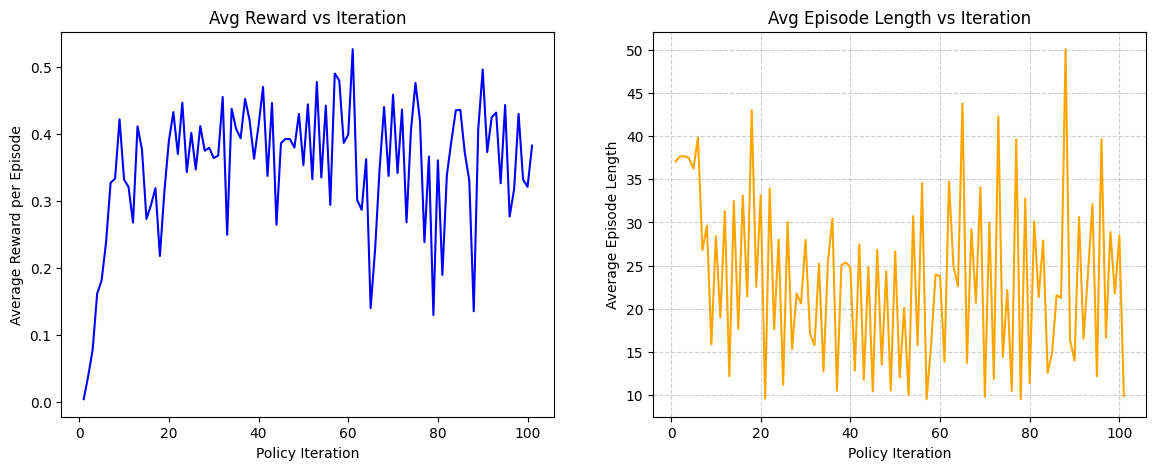

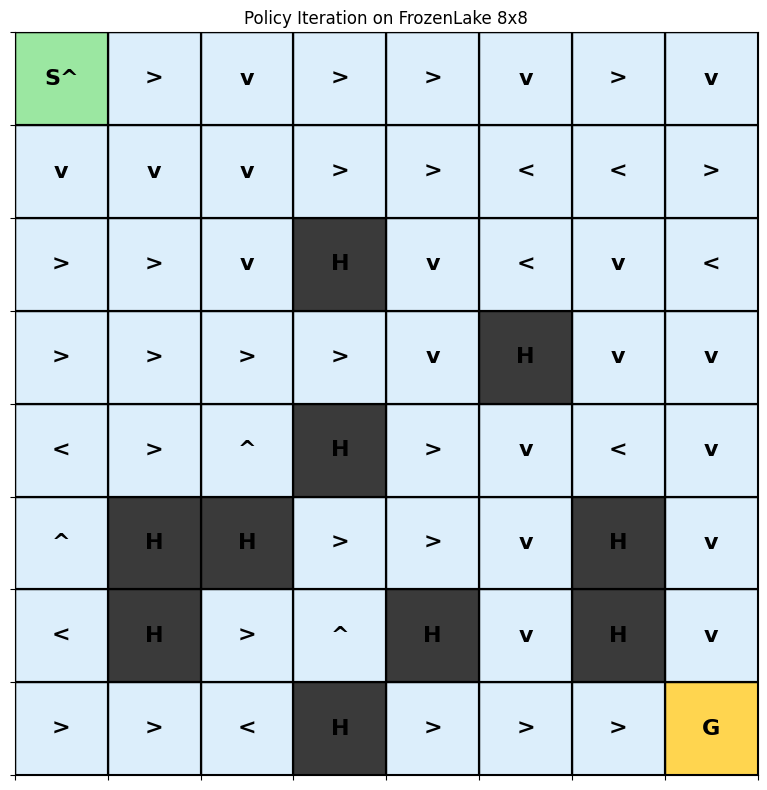

In [50]:
gamma = 0.99
env = build_env(slippery=False)
transition, reward, expected_reward = extract_model(env)

print("FrozenLake-v1 8x8 model")
print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
print("Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action")



q, pi_policy, _ = policy_iteration(env, gamma=gamma)


plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")
